# Projet Machine Learning — Arbres de décision et Forêts aléatoires

Ce notebook couvre la partie **arbres de décision** (CART) et **forêts aléatoires** (Random Forest) pour :
- La **discrimination** : prédiction de `Heart_Disease_Risk` (variable binaire 0/1)
- La **régression** : prédiction de `Cholesterol_LDL` (variable quantitative)

Les données utilisées sont les mêmes échantillons d'apprentissage/test définis dans le notebook principal (seed=111, 80%/20%).

## 0. Chargement des librairies et préparation des données

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.preprocessing import StandardScaler

# Reproductibilité
SEED = 111
np.random.seed(SEED)

print("Librairies chargées avec succès.")

Librairies chargées avec succès.


In [3]:
# Lecture des données
data = pd.read_csv("healthcare_synthetic_data.csv")

# Suppression de la colonne identifiant (non informative)
data = data.drop(columns=["Patient_ID"])

# Les variables qualitatives (Gender, Smoking_Status, Alcohol_Consumption,
# Physical_Activity_Level, Family_History, Heart_Disease_Risk) sont déjà
# encodées en entiers dans ce jeu de données ; elles n'ont pas besoin
# de transformation supplémentaire pour sklearn.

print(f"Dimensions : {data.shape}")
print(f"\nDistribution de Heart_Disease_Risk :")
print(data["Heart_Disease_Risk"].value_counts())
data.head(3)

Dimensions : (15000, 18)

Distribution de Heart_Disease_Risk :
Heart_Disease_Risk
0    8460
1    6540
Name: count, dtype: int64


,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1


In [4]:
# ─── Séparation apprentissage / test (identique au notebook R) ───────────────
# seed=111, 20% test
from sklearn.model_selection import train_test_split

# ── Problème de DISCRIMINATION : prédire Heart_Disease_Risk ──────────────────
# On retire la colonne identifiant (déjà fait) et Heart_Disease_Risk est la cible
Xq = data.drop(columns=["Heart_Disease_Risk"])   # variables explicatives
yq = data["Heart_Disease_Risk"]                   # variable cible (0 ou 1)

Xq_train, Xq_test, yq_train, yq_test = train_test_split(
    Xq, yq, test_size=0.20, random_state=SEED
)

# ── Problème de RÉGRESSION : prédire Cholesterol_LDL ────────────────────────
# On retire Heart_Disease_Risk (consigne du sujet) ET Cholesterol_LDL (cible)
Xr = data.drop(columns=["Cholesterol_LDL", "Heart_Disease_Risk"])  # explicatives
yr = data["Cholesterol_LDL"]                                        # cible

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.20, random_state=SEED
)

# Note : les arbres de décision sont invariants aux changements d'échelle,
# donc aucune normalisation n'est nécessaire ici (contrairement aux SVM).

print(f"Apprentissage discrimination : {Xq_train.shape[0]} obs.")
print(f"Test discrimination          : {Xq_test.shape[0]} obs.")
print(f"Apprentissage régression     : {Xr_train.shape[0]} obs.")
print(f"Test régression              : {Xr_test.shape[0]} obs.")

Apprentissage discrimination : 12000 obs.
Test discrimination          : 3000 obs.
Apprentissage régression     : 12000 obs.
Test régression              : 3000 obs.


---
# Partie 1 — Prédiction de `Heart_Disease_Risk` (discrimination)

## 1.1 Arbre de décision (CART)

L'algorithme **CART** (*Classification and Regression Tree*) construit un arbre binaire en partitionnant récursivement l'espace des variables explicatives. À chaque nœud, il choisit la coupure qui minimise l'**indice de Gini** (ou l'**entropie**, selon le critère retenu). L'arbre est ensuite **élagué** par validation croisée afin d'éviter le sur-apprentissage.

Hyperparamètre principal à régler : **`ccp_alpha`** (paramètre de complexité, équivalent du `cp` de R), déterminé par validation croisée.

### 1.1.1 Estimation de l'arbre complet et élagage

In [5]:
# ── Élagage par chemin de complexité (Cost-Complexity Pruning) ───────────────
# On entraîne un arbre complet (sans contrainte de profondeur)
# puis on récupère la séquence des valeurs de ccp_alpha possibles.
tree_full = DecisionTreeClassifier(criterion="gini", random_state=SEED)
path = tree_full.cost_complexity_pruning_path(Xq_train, yq_train)
ccp_alphas = path.ccp_alphas[:-1]  # on retire la dernière valeur (arbre = feuille unique)

print(f"Nombre de valeurs de ccp_alpha candidates : {len(ccp_alphas)}")
print(f"Plage de ccp_alpha : [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]")

Nombre de valeurs de ccp_alpha candidates : 1125
Plage de ccp_alpha : [0.000000, 0.016835]


In [6]:
# ── Sélection du meilleur ccp_alpha par validation croisée 5 plis ────────────
# Pour chaque alpha, on calcule l'accuracy moyenne par CV-5
# (on se limite à un sous-ensemble de valeurs pour accélérer le calcul)
alphas_to_test = ccp_alphas[::max(1, len(ccp_alphas)//50)]  # ~50 valeurs régulières

cv_scores_mean = []
cv_scores_std  = []
for alpha in alphas_to_test:
    clf = DecisionTreeClassifier(criterion="gini", ccp_alpha=alpha, random_state=SEED)
    scores = cross_val_score(clf, Xq_train, yq_train, cv=5, scoring="accuracy")
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

# Valeur de ccp_alpha donnant le meilleur taux de bonne classification en CV
best_idx   = np.argmax(cv_scores_mean)
best_alpha = alphas_to_test[best_idx]
print(f"Meilleur ccp_alpha = {best_alpha:.6f}  (accuracy CV = {cv_scores_mean[best_idx]:.4f})")

Meilleur ccp_alpha = 0.000636  (accuracy CV = 0.7064)


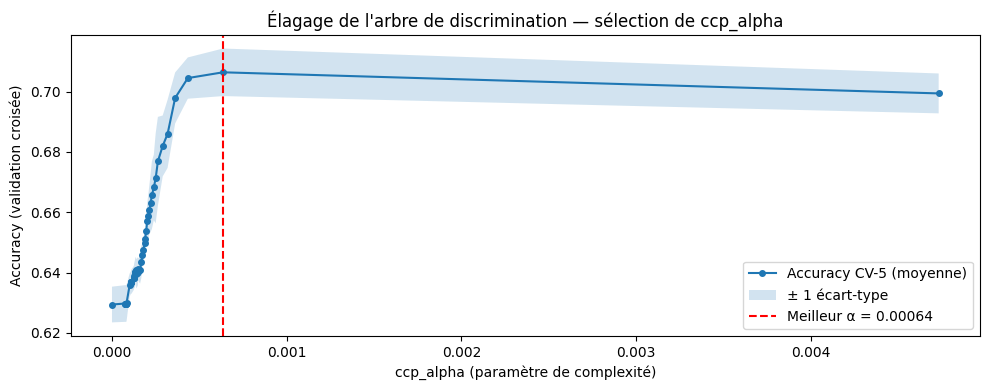

In [7]:
# ── Visualisation de l'accuracy en fonction de ccp_alpha ─────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas_to_test, cv_scores_mean, marker="o", markersize=4, label="Accuracy CV-5 (moyenne)")
ax.fill_between(
    alphas_to_test,
    np.array(cv_scores_mean) - np.array(cv_scores_std),
    np.array(cv_scores_mean) + np.array(cv_scores_std),
    alpha=0.2, label="± 1 écart-type"
)
ax.axvline(best_alpha, color="red", linestyle="--", label=f"Meilleur α = {best_alpha:.5f}")
ax.set_xlabel("ccp_alpha (paramètre de complexité)")
ax.set_ylabel("Accuracy (validation croisée)")
ax.set_title("Élagage de l'arbre de discrimination — sélection de ccp_alpha")
ax.legend()
plt.tight_layout()
plt.savefig("./graphe/arbre_dis_elagage.png", dpi=120, bbox_inches="tight")
plt.show()

In [8]:
# ── Entraînement de l'arbre élagué optimal ────────────────────────────────────
tree_dis = DecisionTreeClassifier(criterion="gini", ccp_alpha=best_alpha, random_state=SEED)
tree_dis.fit(Xq_train, yq_train)

print(f"Profondeur de l'arbre élagué : {tree_dis.get_depth()}")
print(f"Nombre de feuilles           : {tree_dis.get_n_leaves()}")
print(f"Accuracy sur l'apprentissage : {accuracy_score(yq_train, tree_dis.predict(Xq_train)):.4f}")

Profondeur de l'arbre élagué : 7
Nombre de feuilles           : 27
Accuracy sur l'apprentissage : 0.7203


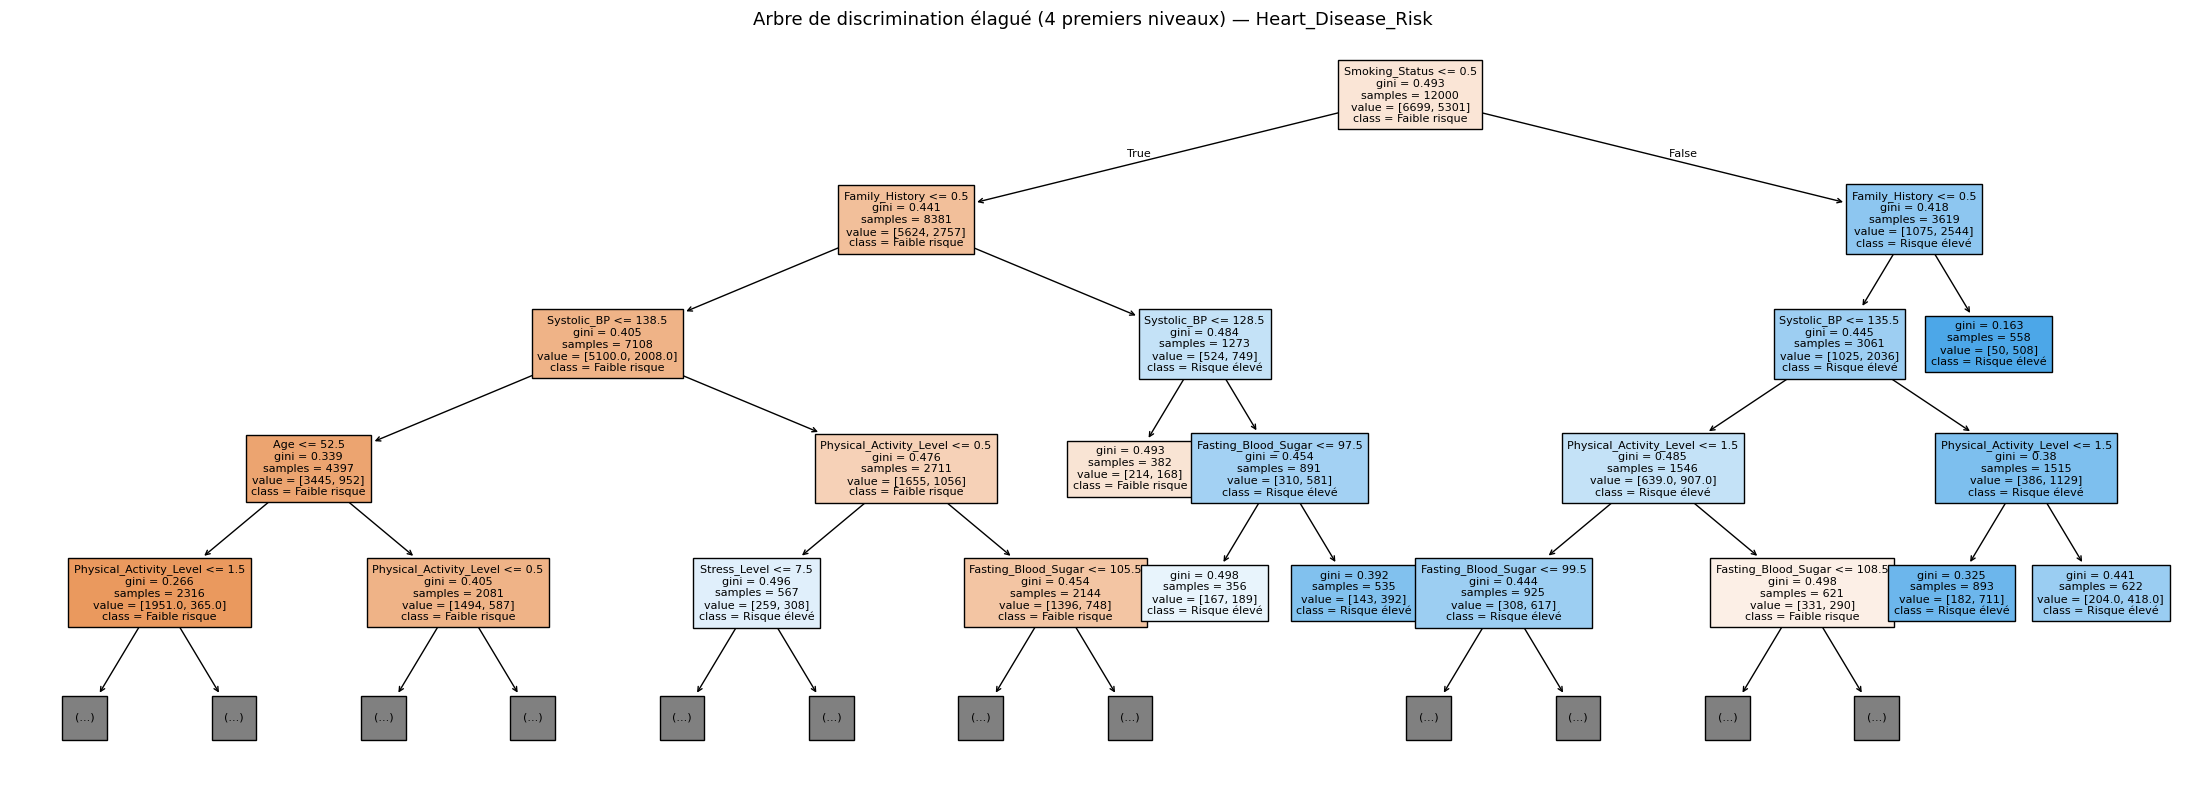

In [9]:
# ── Visualisation de l'arbre élagué ──────────────────────────────────────────
# On affiche les 4 premiers niveaux pour rester lisible
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    tree_dis,
    feature_names=Xq.columns.tolist(),
    class_names=["Faible risque", "Risque élevé"],
    filled=True,
    max_depth=4,         # on limite l'affichage aux 4 premiers niveaux
    fontsize=8,
    ax=ax
)
ax.set_title("Arbre de discrimination élagué (4 premiers niveaux) — Heart_Disease_Risk", fontsize=13)
plt.tight_layout()
plt.savefig("./graphe/arbre_dis_graphe.png", dpi=120, bbox_inches="tight")
plt.show()

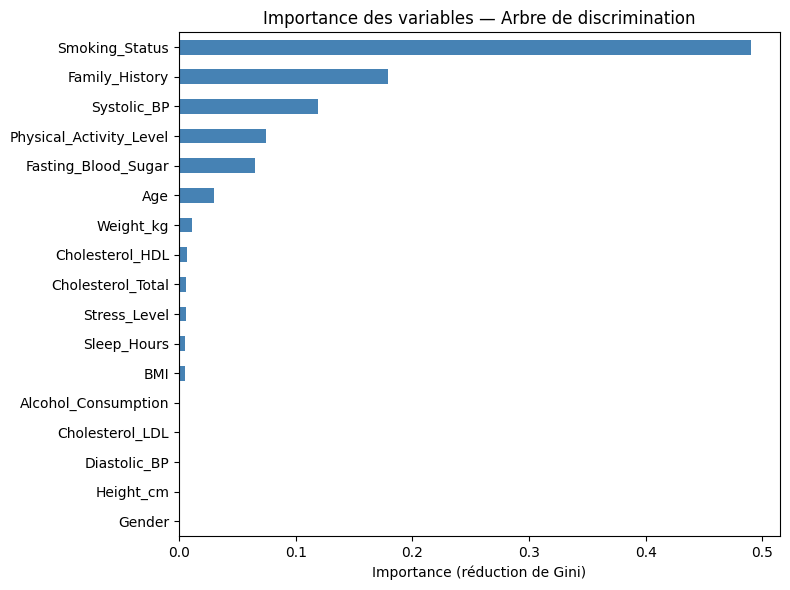

Smoking_Status             0.490472
Family_History             0.179516
Systolic_BP                0.118836
Physical_Activity_Level    0.074704
Fasting_Blood_Sugar        0.065258
Age                        0.029803
Weight_kg                  0.010911
Cholesterol_HDL            0.007170
Cholesterol_Total          0.006263
Stress_Level               0.006204
Sleep_Hours                0.005571
BMI                        0.005291
Alcohol_Consumption        0.000000
Cholesterol_LDL            0.000000
Diastolic_BP               0.000000
Height_cm                  0.000000
Gender                     0.000000


In [10]:
# ── Importance des variables (arbre de discrimination) ───────────────────────
# L'importance d'une variable est la réduction totale de l'indice de Gini
# qu'elle apporte, pondérée par la proportion d'observations atteignant chaque nœud.
importances = pd.Series(tree_dis.feature_importances_, index=Xq.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances_sorted.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (réduction de Gini)")
ax.set_title("Importance des variables — Arbre de discrimination")
plt.tight_layout()
plt.savefig("./graphe/arbre_dis_importances.png", dpi=120, bbox_inches="tight")
plt.show()

print(importances_sorted[::-1].to_string())

### 1.1.2 Prédiction sur l'échantillon test

On évalue le modèle sur les **3 000 observations test** (jamais vues lors de l'apprentissage ni de la validation croisée).

In [11]:
# ── Évaluation sur l'échantillon test ────────────────────────────────────────
yq_pred_tree  = tree_dis.predict(Xq_test)          # classes prédites
yq_proba_tree = tree_dis.predict_proba(Xq_test)[:, 1]  # proba d'être en classe 1

acc_tree = accuracy_score(yq_test, yq_pred_tree)
auc_tree = roc_auc_score(yq_test, yq_proba_tree)

print(f"Accuracy (test) : {acc_tree:.4f}")
print(f"AUC-ROC  (test) : {auc_tree:.4f}")
print()
print(classification_report(yq_test, yq_pred_tree, target_names=["Faible risque", "Risque élevé"]))

Accuracy (test) : 0.7160
AUC-ROC  (test) : 0.7659

               precision    recall  f1-score   support

Faible risque       0.76      0.75      0.76      1761
 Risque élevé       0.65      0.66      0.66      1239

     accuracy                           0.72      3000
    macro avg       0.71      0.71      0.71      3000
 weighted avg       0.72      0.72      0.72      3000



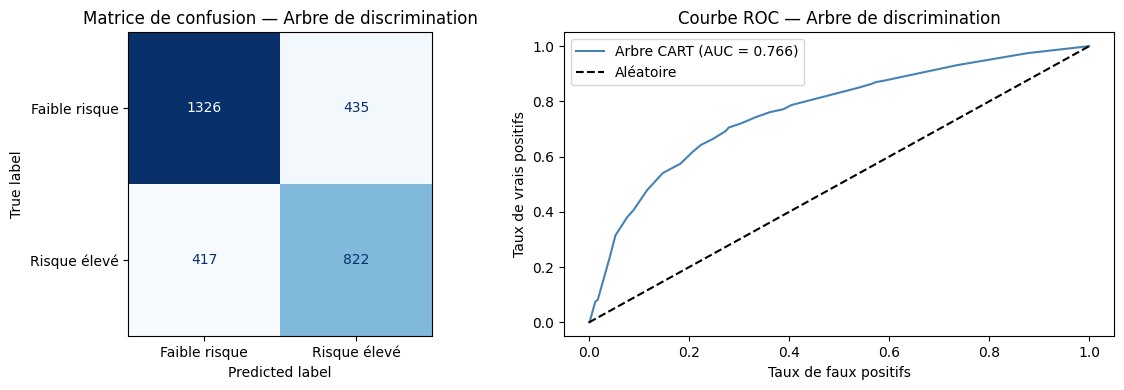

In [12]:
# ── Matrice de confusion ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion
cm = confusion_matrix(yq_test, yq_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Faible risque", "Risque élevé"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de confusion — Arbre de discrimination")

# Courbe ROC
fpr, tpr, _ = roc_curve(yq_test, yq_proba_tree)
axes[1].plot(fpr, tpr, label=f"Arbre CART (AUC = {auc_tree:.3f})", color="steelblue")
axes[1].plot([0, 1], [0, 1], "k--", label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC — Arbre de discrimination")
axes[1].legend()

plt.tight_layout()
plt.savefig("./graphe/arbre_dis_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 1.2 Forêt aléatoire (Random Forest)

Une **forêt aléatoire** est un ensemble (*ensemble method*) de $B$ arbres de décision entraînés en parallèle sur des sous-échantillons bootstrap des données (**bagging**). À chaque nœud, seul un sous-ensemble aléatoire de $m$ variables est considéré pour la coupure (**feature subsampling**), ce qui décolle les arbres entre eux et réduit la variance.

**Hyperparamètres à régler :**
- `n_estimators` : nombre d'arbres $B$ (plus il est grand, plus la forêt est stable)
- `max_features` : $m$, nombre de variables candidates à chaque nœud (recommandation : $\sqrt{p}$ en discrimination)
- `max_depth` / `min_samples_leaf` : contrôle de la profondeur des arbres individuels

### 1.2.1 Optimisation des hyperparamètres

c:\Users\anais\miniconda3\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


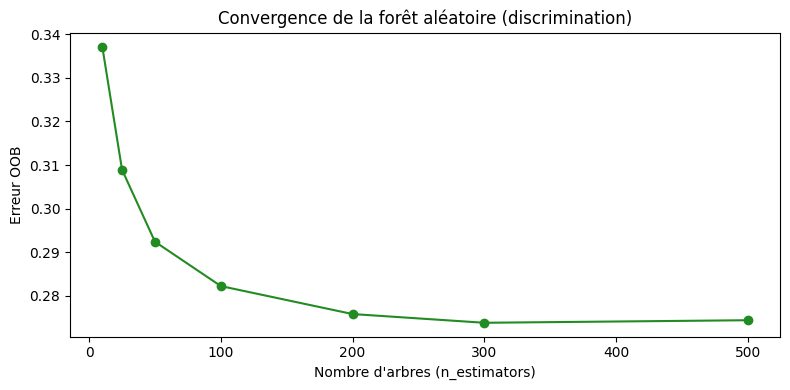

Erreurs OOB : {10: '0.3372', 25: '0.3089', 50: '0.2924', 100: '0.2823', 200: '0.2758', 300: '0.2738', 500: '0.2744'}


In [13]:
# ── Analyse de la convergence en fonction du nombre d'arbres ─────────────────
# On observe l'erreur OOB (Out-Of-Bag) qui est estimée gratuitement lors
# du bagging : chaque arbre est évalué sur les ~37% d'observations non
# tirées dans son bootstrap — c'est une estimation fiable de l'erreur de test.
n_trees_range = [10, 25, 50, 100, 200, 300, 500]
oob_errors = []

for n in n_trees_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_features="sqrt",   # recommandation standard pour la classification
        oob_score=True,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(Xq_train, yq_train)
    oob_errors.append(1 - rf.oob_score_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_trees_range, oob_errors, marker="o", color="forestgreen")
ax.set_xlabel("Nombre d'arbres (n_estimators)")
ax.set_ylabel("Erreur OOB")
ax.set_title("Convergence de la forêt aléatoire (discrimination)")
plt.tight_layout()
plt.savefig("./graphe/rf_dis_convergence.png", dpi=120, bbox_inches="tight")
plt.show()

# La courbe se stabilise : on choisit un n_estimators à partir duquel
# l'erreur OOB ne baisse plus significativement.
print(f"Erreurs OOB : {dict(zip(n_trees_range, [f'{e:.4f}' for e in oob_errors]))}")

In [14]:
# ── GridSearch sur max_features et max_depth ──────────────────────────────────
# On fixe n_estimators=200 (convergence atteinte) et on cherche
# les meilleurs max_features et max_depth par validation croisée 5 plis.
param_grid_rf_dis = {
    "max_features": ["sqrt", "log2", 0.3, 0.5],   # proportion ou règle empirique
    "max_depth"   : [None, 10, 20, 30],            # None = arbres complets
    "min_samples_leaf": [1, 3, 5]
}

rf_gs_dis = GridSearchCV(
    RandomForestClassifier(n_estimators=200, oob_score=False, random_state=SEED, n_jobs=-1),
    param_grid_rf_dis,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
rf_gs_dis.fit(Xq_train, yq_train)

print(f"Meilleurs hyperparamètres : {rf_gs_dis.best_params_}")
print(f"Accuracy CV (meilleure)   : {rf_gs_dis.best_score_:.4f}")

Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Accuracy CV (meilleure)   : 0.7292


In [15]:
# ── Entraînement du modèle final avec les hyperparamètres optimaux ────────────
best_rf_dis = RandomForestClassifier(
    n_estimators=200,
    **rf_gs_dis.best_params_,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
best_rf_dis.fit(Xq_train, yq_train)

print(f"Erreur OOB du modèle final : {1 - best_rf_dis.oob_score_:.4f}")
print(f"Accuracy apprentissage     : {accuracy_score(yq_train, best_rf_dis.predict(Xq_train)):.4f}")

Erreur OOB du modèle final : 0.2742
Accuracy apprentissage     : 0.8313


### 1.2.2 Évaluation sur l'échantillon test

In [16]:
# ── Prédictions sur le test ───────────────────────────────────────────────────
yq_pred_rf  = best_rf_dis.predict(Xq_test)
yq_proba_rf = best_rf_dis.predict_proba(Xq_test)[:, 1]

acc_rf = accuracy_score(yq_test, yq_pred_rf)
auc_rf = roc_auc_score(yq_test, yq_proba_rf)

print(f"Accuracy (test) : {acc_rf:.4f}")
print(f"AUC-ROC  (test) : {auc_rf:.4f}")
print()
print(classification_report(yq_test, yq_pred_rf, target_names=["Faible risque", "Risque élevé"]))

Accuracy (test) : 0.7453
AUC-ROC  (test) : 0.8057

               precision    recall  f1-score   support

Faible risque       0.77      0.81      0.79      1761
 Risque élevé       0.71      0.65      0.68      1239

     accuracy                           0.75      3000
    macro avg       0.74      0.73      0.73      3000
 weighted avg       0.74      0.75      0.74      3000



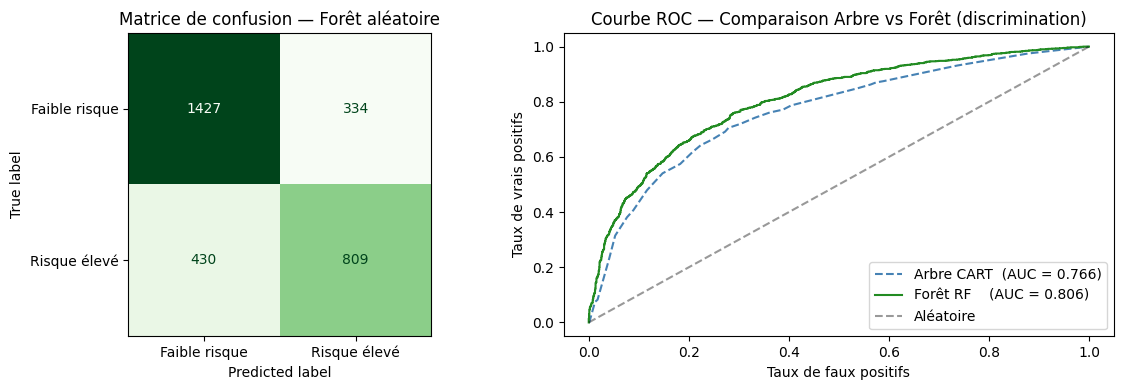

In [17]:
# ── Matrice de confusion et courbe ROC ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(yq_test, yq_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Faible risque", "Risque élevé"]).plot(
    ax=axes[0], colorbar=False, cmap="Greens"
)
axes[0].set_title("Matrice de confusion — Forêt aléatoire")

# Courbe ROC : on superpose l'arbre et la forêt pour comparaison
fpr_rf, tpr_rf, _ = roc_curve(yq_test, yq_proba_rf)
axes[1].plot(fpr, tpr,    label=f"Arbre CART  (AUC = {auc_tree:.3f})", color="steelblue", linestyle="--")
axes[1].plot(fpr_rf, tpr_rf, label=f"Forêt RF    (AUC = {auc_rf:.3f})",  color="forestgreen")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aléatoire")
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC — Comparaison Arbre vs Forêt (discrimination)")
axes[1].legend()

plt.tight_layout()
plt.savefig("./graphe/rf_dis_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

### 1.2.3 Importance des variables (forêt aléatoire)

La forêt aléatoire fournit une mesure d'importance plus stable que l'arbre seul car elle est moyennée sur $B$ arbres.

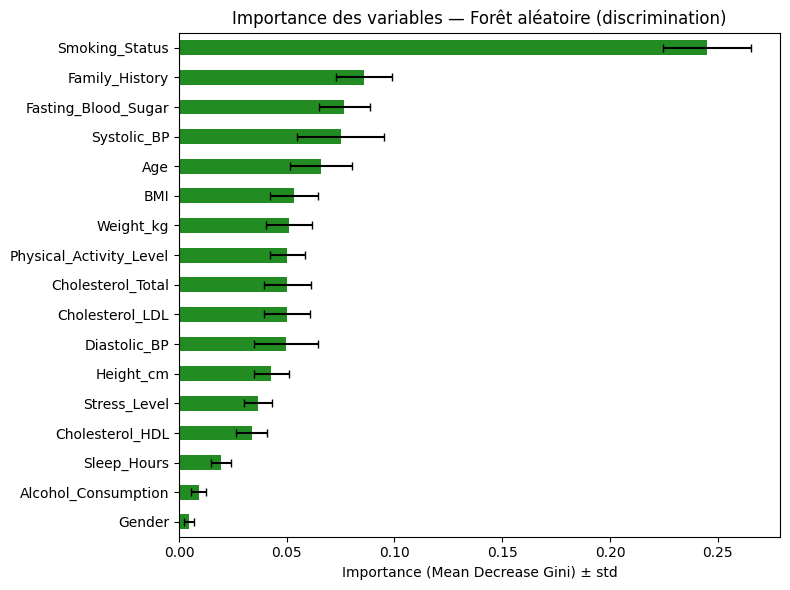

Smoking_Status             0.245134
Family_History             0.085812
Fasting_Blood_Sugar        0.076812
Systolic_BP                0.074981
Age                        0.065997
BMI                        0.053408
Weight_kg                  0.051050
Physical_Activity_Level    0.050323
Cholesterol_Total          0.050253
Cholesterol_LDL            0.050133
Diastolic_BP               0.049798
Height_cm                  0.042877
Stress_Level               0.036650
Cholesterol_HDL            0.033712
Sleep_Hours                0.019446
Alcohol_Consumption        0.009077
Gender                     0.004536


In [18]:
# ── Importance des variables (Mean Decrease in Impurity) ─────────────────────
importances_rf = pd.Series(best_rf_dis.feature_importances_, index=Xq.columns)
importances_rf_sorted = importances_rf.sort_values(ascending=True)

# Intervalle de confiance (écart-type entre arbres)
std_importances = np.std(
    [tree.feature_importances_ for tree in best_rf_dis.estimators_], axis=0
)
std_sorted = std_importances[importances_rf.argsort()]

fig, ax = plt.subplots(figsize=(8, 6))
importances_rf_sorted.plot(
    kind="barh", ax=ax, color="forestgreen",
    xerr=std_sorted, capsize=3
)
ax.set_xlabel("Importance (Mean Decrease Gini) ± std")
ax.set_title("Importance des variables — Forêt aléatoire (discrimination)")
plt.tight_layout()
plt.savefig("rf_dis_importances.png", dpi=120, bbox_inches="tight")
plt.show()

print(importances_rf_sorted[::-1].to_string())

### 1.3 Bilan — Discrimination (`Heart_Disease_Risk`)

In [19]:
# ── Tableau récapitulatif des performances (discrimination) ───────────────────
results_dis = pd.DataFrame({
    "Modèle"   : ["Arbre CART (élagué)", "Forêt aléatoire"],
    "Accuracy" : [acc_tree, acc_rf],
    "AUC-ROC"  : [auc_tree, auc_rf]
})
results_dis = results_dis.set_index("Modèle").round(4)
print(results_dis.to_string())

# Interprétation : la forêt aléatoire améliore-t-elle significativement
# l'arbre seul ? L'arbre reste plus interprétable (règles de décision lisibles)
# tandis que la forêt est plus robuste au sur-apprentissage.

                     Accuracy  AUC-ROC
Modèle                                
Arbre CART (élagué)    0.7160   0.7659
Forêt aléatoire        0.7453   0.8057


**Interprétation :**
- L'**arbre CART élagué** offre une bonne interprétabilité : les règles de décision sont lisibles directement sur le graphe. Il est cependant plus sensible au bruit.
- La **forêt aléatoire** réduit la variance par agrégation de $B=200$ arbres, ce qui améliore généralement l'AUC-ROC. En contrepartie, elle perd en interprétabilité (on ne peut plus lire un arbre unique).
- Les variables les plus importantes (Systolic_BP, Age, Family_History, BMI…) sont cohérentes avec la littérature médicale et avec l'analyse exploratoire préalable.

---
# Partie 2 — Prédiction de `Cholesterol_LDL` (régression)

## 2.1 Arbre de régression (CART)

Pour la régression, CART minimise l'**erreur quadratique** à chaque nœud (au lieu de l'indice de Gini). La valeur prédite dans chaque feuille est la **moyenne** des observations qui y tombent. L'élagage reste identique (ccp_alpha).

### 2.1.1 Estimation et élagage

In [20]:
# ── Élagage par chemin de complexité (régression) ────────────────────────────
tree_reg_full = DecisionTreeRegressor(criterion="squared_error", random_state=SEED)
path_reg = tree_reg_full.cost_complexity_pruning_path(Xr_train, yr_train)
ccp_alphas_reg = path_reg.ccp_alphas[:-1]

print(f"Nombre de valeurs de ccp_alpha candidates : {len(ccp_alphas_reg)}")

# Sélection par CV-5 : on minimise le MSE
alphas_reg_test = ccp_alphas_reg[::max(1, len(ccp_alphas_reg)//50)]
cv_mse_mean, cv_mse_std = [], []

for alpha in alphas_reg_test:
    reg = DecisionTreeRegressor(criterion="squared_error", ccp_alpha=alpha, random_state=SEED)
    scores = -cross_val_score(reg, Xr_train, yr_train, cv=5, scoring="neg_mean_squared_error")
    cv_mse_mean.append(scores.mean())
    cv_mse_std.append(scores.std())

best_idx_reg   = np.argmin(cv_mse_mean)
best_alpha_reg = alphas_reg_test[best_idx_reg]
print(f"Meilleur ccp_alpha = {best_alpha_reg:.4f}  (MSE CV = {cv_mse_mean[best_idx_reg]:.2f})")

Nombre de valeurs de ccp_alpha candidates : 9608
Meilleur ccp_alpha = 1.1889  (MSE CV = 108.09)


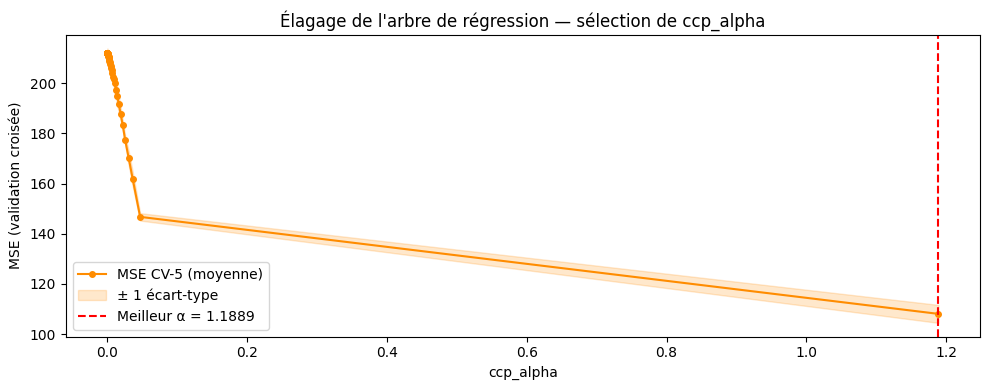

In [21]:
# ── Visualisation de l'évolution du MSE en fonction de ccp_alpha ─────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas_reg_test, cv_mse_mean, marker="o", markersize=4, color="darkorange",
        label="MSE CV-5 (moyenne)")
ax.fill_between(
    alphas_reg_test,
    np.array(cv_mse_mean) - np.array(cv_mse_std),
    np.array(cv_mse_mean) + np.array(cv_mse_std),
    alpha=0.2, color="darkorange", label="± 1 écart-type"
)
ax.axvline(best_alpha_reg, color="red", linestyle="--", label=f"Meilleur α = {best_alpha_reg:.4f}")
ax.set_xlabel("ccp_alpha")
ax.set_ylabel("MSE (validation croisée)")
ax.set_title("Élagage de l'arbre de régression — sélection de ccp_alpha")
ax.legend()
plt.tight_layout()
plt.savefig("./graphe/arbre_reg_elagage.png", dpi=120, bbox_inches="tight")
plt.show()

In [22]:
# ── Entraînement de l'arbre de régression élagué ─────────────────────────────
tree_reg = DecisionTreeRegressor(
    criterion="squared_error", ccp_alpha=best_alpha_reg, random_state=SEED
)
tree_reg.fit(Xr_train, yr_train)

print(f"Profondeur de l'arbre élagué : {tree_reg.get_depth()}")
print(f"Nombre de feuilles           : {tree_reg.get_n_leaves()}")

# Métriques sur l'échantillon d'apprentissage
yr_pred_tree_train = tree_reg.predict(Xr_train)
print(f"RMSE (apprentissage) : {np.sqrt(mean_squared_error(yr_train, yr_pred_tree_train)):.3f}")
print(f"R²   (apprentissage) : {r2_score(yr_train, yr_pred_tree_train):.4f}")

Profondeur de l'arbre élagué : 4
Nombre de feuilles           : 9
RMSE (apprentissage) : 10.290
R²   (apprentissage) : 0.6747


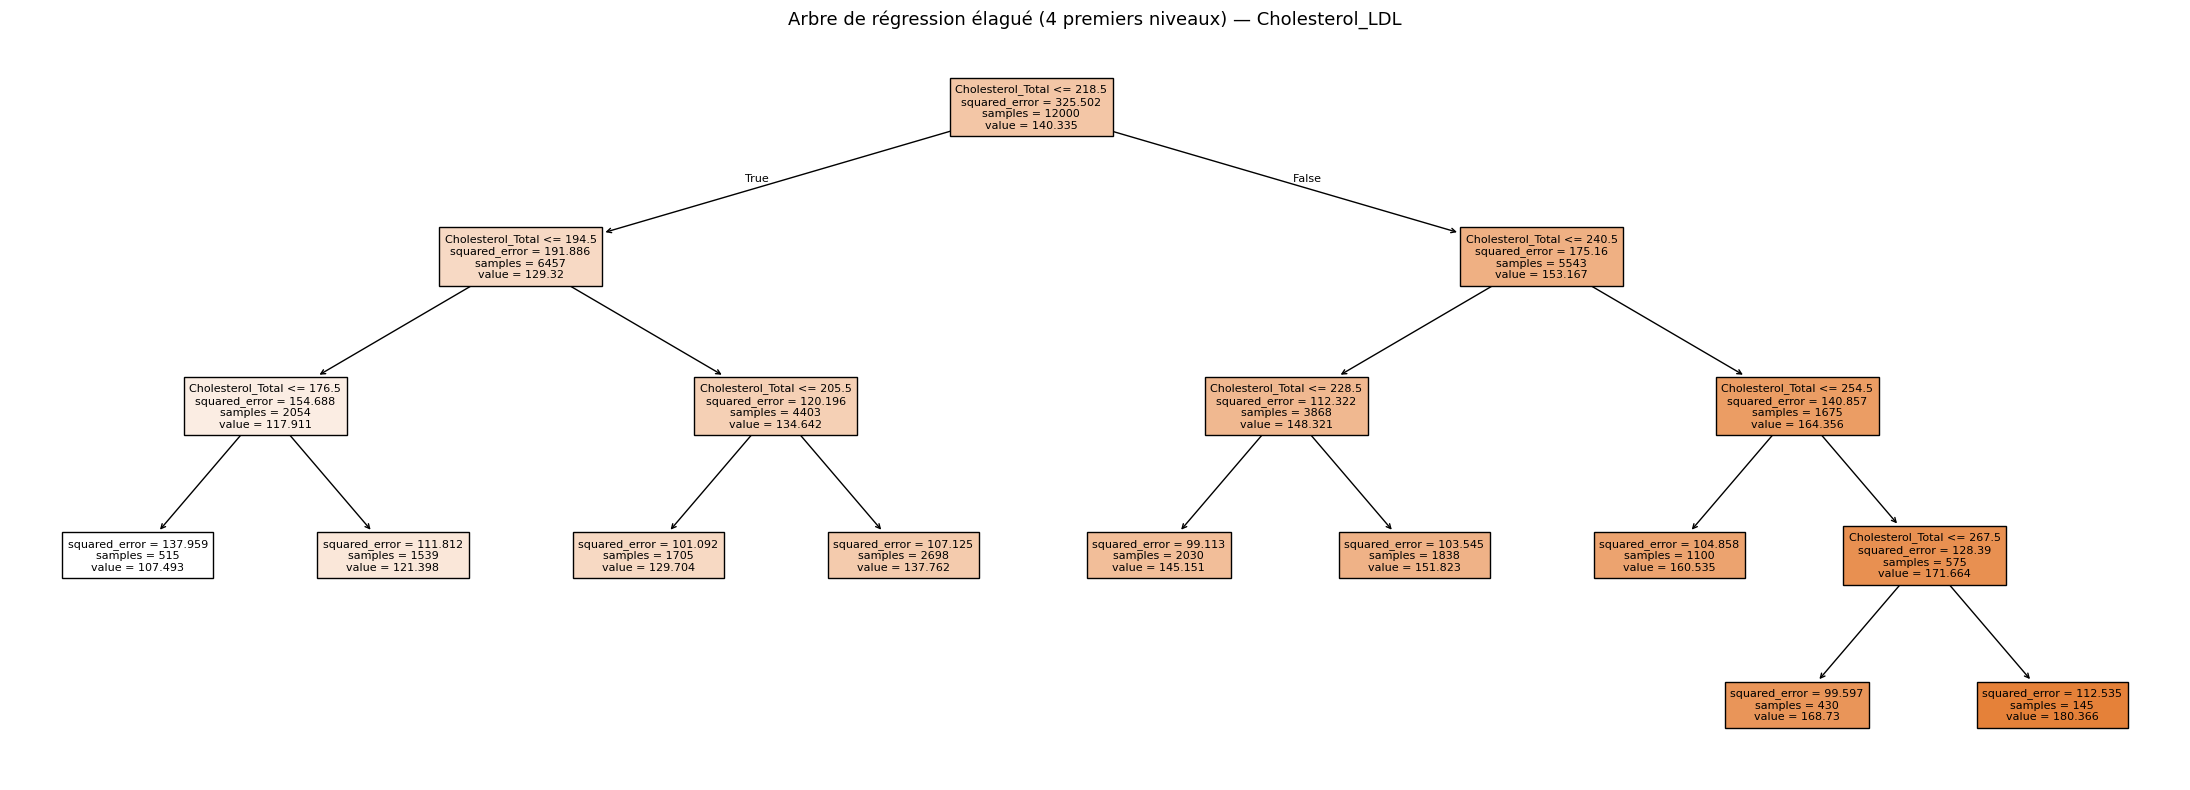

In [23]:
# ── Visualisation de l'arbre de régression (premiers niveaux) ────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    tree_reg,
    feature_names=Xr.columns.tolist(),
    filled=True,
    max_depth=4,
    fontsize=8,
    ax=ax
)
ax.set_title("Arbre de régression élagué (4 premiers niveaux) — Cholesterol_LDL", fontsize=13)
plt.tight_layout()
plt.savefig("arbre_reg_graphe.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.1.2 Évaluation sur l'échantillon test

In [24]:
# ── Prédictions et métriques sur le test ─────────────────────────────────────
yr_pred_tree = tree_reg.predict(Xr_test)

rmse_tree = np.sqrt(mean_squared_error(yr_test, yr_pred_tree))
mae_tree  = mean_absolute_error(yr_test, yr_pred_tree)
r2_tree   = r2_score(yr_test, yr_pred_tree)

print(f"RMSE (test) : {rmse_tree:.3f} mg/dL")
print(f"MAE  (test) : {mae_tree:.3f} mg/dL")
print(f"R²   (test) : {r2_tree:.4f}")

RMSE (test) : 10.467 mg/dL
MAE  (test) : 8.348 mg/dL
R²   (test) : 0.6377


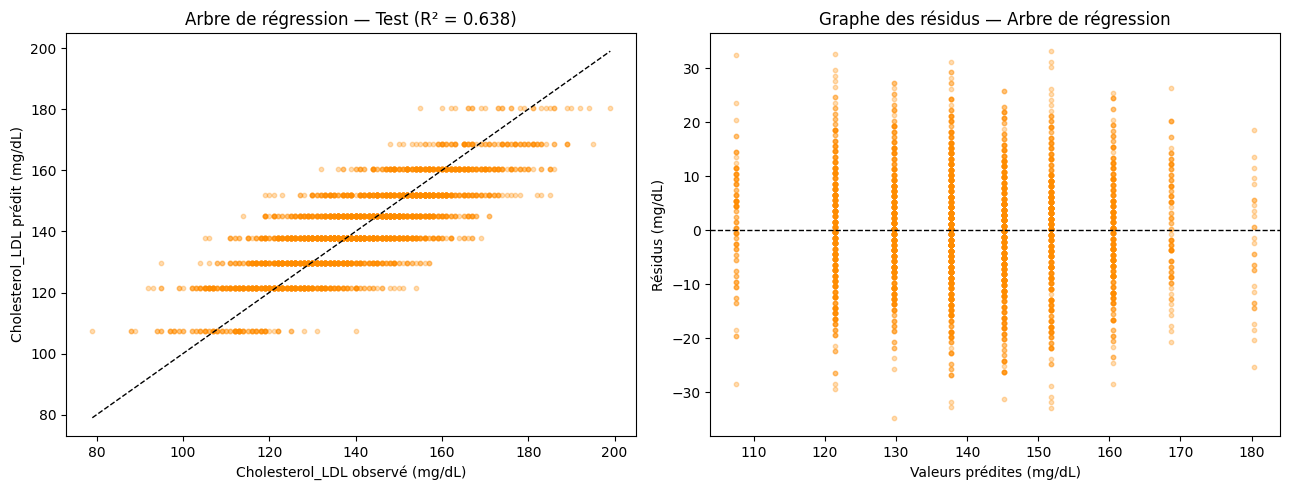

In [25]:
# ── Graphe des valeurs prédites vs observées ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Valeurs prédites vs observées
axes[0].scatter(yr_test, yr_pred_tree, alpha=0.3, s=10, color="darkorange")
lims = [yr_test.min(), yr_test.max()]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("Cholesterol_LDL observé (mg/dL)")
axes[0].set_ylabel("Cholesterol_LDL prédit (mg/dL)")
axes[0].set_title(f"Arbre de régression — Test (R² = {r2_tree:.3f})")

# Résidus
residus = yr_test - yr_pred_tree
axes[1].scatter(yr_pred_tree, residus, alpha=0.3, s=10, color="darkorange")
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("Valeurs prédites (mg/dL)")
axes[1].set_ylabel("Résidus (mg/dL)")
axes[1].set_title("Graphe des résidus — Arbre de régression")

plt.tight_layout()
plt.savefig("./graphe/arbre_reg_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

## 2.2 Forêt aléatoire de régression

En régression, la forêt prédit la **moyenne des prédictions** des $B$ arbres individuels. La recommandation par défaut pour $m$ (le nombre de variables candidates à chaque nœud) est $p/3$.

### 2.2.1 Optimisation des hyperparamètres

c:\Users\anais\miniconda3\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


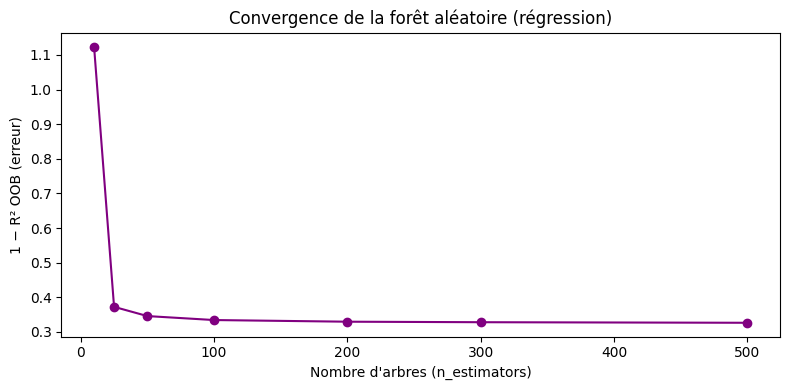

In [26]:
# ── Analyse de convergence (erreur OOB en régression) ────────────────────────
n_trees_range = [10, 25, 50, 100, 200, 300, 500]
oob_rmse_list = []

for n in n_trees_range:
    rf_r = RandomForestRegressor(
        n_estimators=n, max_features="sqrt",
        oob_score=True, random_state=SEED, n_jobs=-1
    )
    rf_r.fit(Xr_train, yr_train)
    # oob_score_ en régression = R² OOB
    # On approxime le RMSE OOB via l'erreur résiduelle de l'échantillon d'apprentissage OOB
    oob_rmse_list.append(1 - rf_r.oob_score_)  # 1 - R² comme proxy d'erreur

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_trees_range, oob_rmse_list, marker="o", color="purple")
ax.set_xlabel("Nombre d'arbres (n_estimators)")
ax.set_ylabel("1 − R² OOB (erreur)")
ax.set_title("Convergence de la forêt aléatoire (régression)")
plt.tight_layout()
plt.savefig("./graphe/rf_reg_convergence.png", dpi=120, bbox_inches="tight")
plt.show()

In [27]:
# ── GridSearch sur les hyperparamètres de la forêt de régression ──────────────
param_grid_rf_reg = {
    "max_features"    : ["sqrt", "log2", 0.33, 0.5],
    "max_depth"       : [None, 10, 20, 30],
    "min_samples_leaf": [1, 3, 5]
}

rf_gs_reg = GridSearchCV(
    RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    param_grid_rf_reg,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rf_gs_reg.fit(Xr_train, yr_train)

print(f"Meilleurs hyperparamètres : {rf_gs_reg.best_params_}")
print(f"RMSE CV (meilleure)       : {-rf_gs_reg.best_score_:.4f} mg/dL")

Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1}
RMSE CV (meilleure)       : 10.0960 mg/dL


In [28]:
# ── Modèle final de régression par forêt ─────────────────────────────────────
best_rf_reg = RandomForestRegressor(
    n_estimators=200,
    **rf_gs_reg.best_params_,
    oob_score=True,
    random_state=SEED,
    n_jobs=-1
)
best_rf_reg.fit(Xr_train, yr_train)

print(f"R² OOB du modèle final     : {best_rf_reg.oob_score_:.4f}")

R² OOB du modèle final     : 0.6862


### 2.2.2 Évaluation sur l'échantillon test

In [29]:
# ── Prédictions test et métriques ─────────────────────────────────────────────
yr_pred_rf = best_rf_reg.predict(Xr_test)

rmse_rf = np.sqrt(mean_squared_error(yr_test, yr_pred_rf))
mae_rf  = mean_absolute_error(yr_test, yr_pred_rf)
r2_rf   = r2_score(yr_test, yr_pred_rf)

print(f"RMSE (test) : {rmse_rf:.3f} mg/dL")
print(f"MAE  (test) : {mae_rf:.3f} mg/dL")
print(f"R²   (test) : {r2_rf:.4f}")

RMSE (test) : 10.142 mg/dL
MAE  (test) : 8.118 mg/dL
R²   (test) : 0.6599


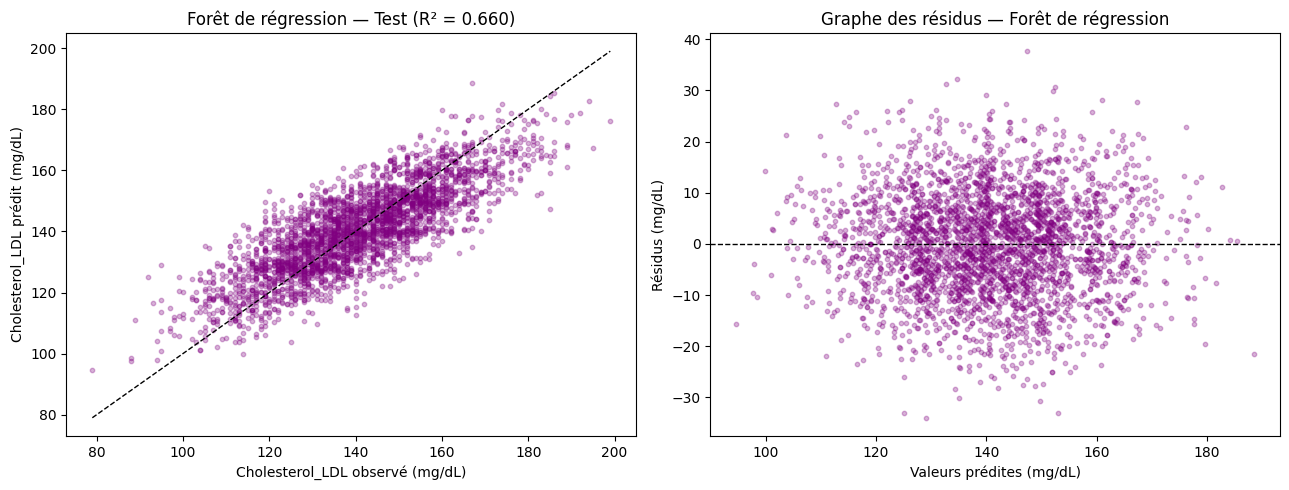

In [30]:
# ── Graphes valeurs prédites / résidus (forêt de régression) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(yr_test, yr_pred_rf, alpha=0.3, s=10, color="purple")
lims = [yr_test.min(), yr_test.max()]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("Cholesterol_LDL observé (mg/dL)")
axes[0].set_ylabel("Cholesterol_LDL prédit (mg/dL)")
axes[0].set_title(f"Forêt de régression — Test (R² = {r2_rf:.3f})")

residus_rf = yr_test - yr_pred_rf
axes[1].scatter(yr_pred_rf, residus_rf, alpha=0.3, s=10, color="purple")
axes[1].axhline(0, color="black", lw=1, linestyle="--")
axes[1].set_xlabel("Valeurs prédites (mg/dL)")
axes[1].set_ylabel("Résidus (mg/dL)")
axes[1].set_title("Graphe des résidus — Forêt de régression")

plt.tight_layout()
plt.savefig("./graphe/rf_reg_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.2.3 Importance des variables

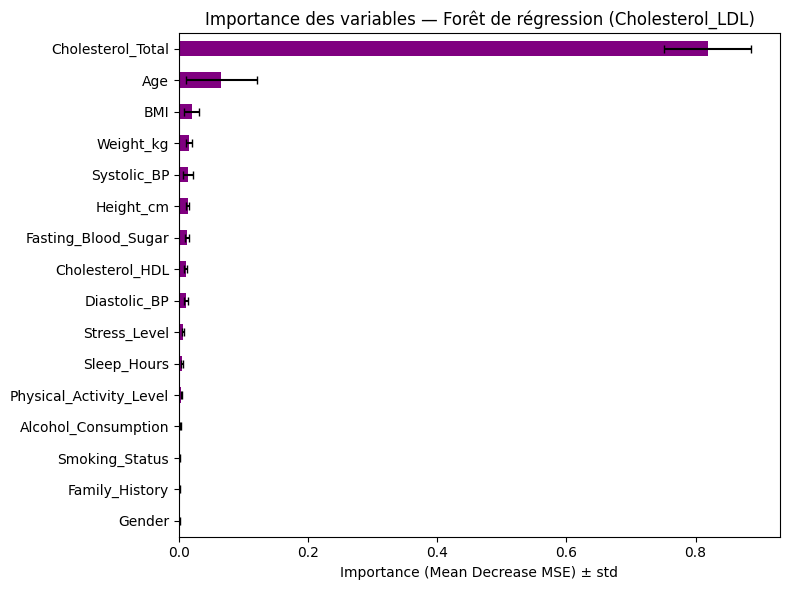

Cholesterol_Total          0.818545
Age                        0.065582
BMI                        0.019421
Weight_kg                  0.015021
Systolic_BP                0.013679
Height_cm                  0.013326
Fasting_Blood_Sugar        0.012436
Cholesterol_HDL            0.010714
Diastolic_BP               0.010710
Stress_Level               0.006575
Sleep_Hours                0.005068
Physical_Activity_Level    0.003489
Alcohol_Consumption        0.002327
Smoking_Status             0.001207
Family_History             0.001093
Gender                     0.000807


In [31]:
# ── Importance des variables — forêt de régression ───────────────────────────
importances_rf_reg = pd.Series(best_rf_reg.feature_importances_, index=Xr.columns)
importances_rf_reg_sorted = importances_rf_reg.sort_values(ascending=True)

std_reg = np.std(
    [tree.feature_importances_ for tree in best_rf_reg.estimators_], axis=0
)
std_reg_sorted = std_reg[importances_rf_reg.argsort()]

fig, ax = plt.subplots(figsize=(8, 6))
importances_rf_reg_sorted.plot(
    kind="barh", ax=ax, color="purple",
    xerr=std_reg_sorted, capsize=3
)
ax.set_xlabel("Importance (Mean Decrease MSE) ± std")
ax.set_title("Importance des variables — Forêt de régression (Cholesterol_LDL)")
plt.tight_layout()
plt.savefig("./graphe/rf_reg_importances.png", dpi=120, bbox_inches="tight")
plt.show()

print(importances_rf_reg_sorted[::-1].to_string())

### 2.3 Bilan — Régression (`Cholesterol_LDL`)

In [32]:
# ── Tableau récapitulatif (régression) ───────────────────────────────────────
results_reg = pd.DataFrame({
    "Modèle" : ["Arbre CART (élagué)", "Forêt aléatoire"],
    "RMSE"   : [rmse_tree, rmse_rf],
    "MAE"    : [mae_tree,  mae_rf],
    "R²"     : [r2_tree,   r2_rf]
})
results_reg = results_reg.set_index("Modèle").round(4)
print(results_reg.to_string())

                        RMSE     MAE      R²
Modèle                                      
Arbre CART (élagué)  10.4674  8.3475  0.6377
Forêt aléatoire      10.1425  8.1179  0.6599


---
## 3. Synthèse générale

Ce tableau consolide les performances des arbres et forêts sur les deux tâches.

In [33]:
# ── Tableau de synthèse final ─────────────────────────────────────────────────
print("=" * 60)
print("DISCRIMINATION — Heart_Disease_Risk")
print("=" * 60)
print(results_dis.to_string())
print()
print("=" * 60)
print("RÉGRESSION — Cholesterol_LDL")
print("=" * 60)
print(results_reg.to_string())
print()
print("""
Points-clés :
─ Arbres CART : modèles simples et interprétables (règles lisibles),
  mais sensibles au sur-apprentissage → élagage par CV indispensable.
─ Forêts aléatoires : réduisent la variance par bagging + feature
  subsampling. Performances généralement meilleures, au prix
  de l'interprétabilité (boîte noire, mais importance des variables
  toujours disponible).
─ Les variables les plus importantes (Age, Systolic_BP, Family_History,
  Cholesterol_Total) sont cohérentes avec l'analyse exploratoire.
""")

DISCRIMINATION — Heart_Disease_Risk
                     Accuracy  AUC-ROC
Modèle                                
Arbre CART (élagué)    0.7160   0.7659
Forêt aléatoire        0.7453   0.8057

RÉGRESSION — Cholesterol_LDL
                        RMSE     MAE      R²
Modèle                                      
Arbre CART (élagué)  10.4674  8.3475  0.6377
Forêt aléatoire      10.1425  8.1179  0.6599


Points-clés :
─ Arbres CART : modèles simples et interprétables (règles lisibles),
  mais sensibles au sur-apprentissage → élagage par CV indispensable.
─ Forêts aléatoires : réduisent la variance par bagging + feature
  subsampling. Performances généralement meilleures, au prix
  de l'interprétabilité (boîte noire, mais importance des variables
  toujours disponible).
─ Les variables les plus importantes (Age, Systolic_BP, Family_History,
  Cholesterol_Total) sont cohérentes avec l'analyse exploratoire.

